In [1]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import math
import pandas as pd
import matplotlib as mpl
import os
import pingouin
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [58]:
# ----- DEFINE FUNCTIONS -----

def testNormal(input, alpha=0.05):
    if len(input) >= 20:
        #This function is based on D’Agostino and Pearson’s test that combines skew and kurtosis to produce an omnibus test of normality
        results = scipy.stats.normaltest(input) 
        p_values = results.pvalue
        normal_method = "D'Agostino-Pearson test (combined kurtosis + skewness)"
        if p_value > alpha: isnormal = True
        elif p_value <= alpha: isnormal = False
    else: 
        #For n<20, we have to rely on a Monte Carlo approach to test skew and kurtosis (kurtosistest is only valid n>=20) 
        rvs = lambda size: scipy.stats.norm.rvs(size=size, random_state=np.random.default_rng())
        skew_results = scipy.stats.monte_carlo_test(input, rvs, scipy.stats.skew, vectorized=True)
        kurtosis_results = scipy.stats.monte_carlo_test(input, rvs, scipy.stats.kurtosis, vectorized=True)
        p_values = [skew_results.pvalue, kurtosis_results.pvalue]
        normal_method = "Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness)"
        # data is only treated as normal if it has both normal skew and kurtosis
        if p_values[0] > 0.05 and p_values[1] > alpha: isnormal = True
        else: isnormal = False
    return isnormal, p_values, normal_method

def decide_pval_text(pval,palpha):

    if pval>palpha:
        ptxt = 'n.s.'
    elif palpha/50<pval<palpha:
        ptxt='*'
    elif palpha/500<pval<palpha/50:
        ptxt ='**'
    elif palpha/5000<pval<palpha/500:
        ptxt = '***'
    else:
        ptxt = '****'

    return ptxt
    

def make_PPT_chamber_stat_plots(df,cols,fname,savefigs,printstats,ttl,ylab):
    
    xlab = ''
    
    # do normality testing and statistical testing
    df['diff'] = df['Het']-df['WT']
    isnormal, p_values, normal_method = testNormal(df['diff'])

    if isnormal:
        statsresults = scipy.stats.ttest_rel(df['Het'], df['WT']) # run a paired ttest if the data passed normality
    else:
        statsresults = scipy.stats.wilcoxon(df['Het'], y=df['WT']) # run a wilcoxon sign rank test if not
        
    if printstats:
        print(statsresults)

    pval = statsresults[1]
    if pval>palpha:
        ptxt = 'n.s.'
    elif palpha/10<pval<palpha:
        ptxt='*'
    elif palpha/100<pval<palpha/10:
        ptxt ='**'

    # make figure
    fig, ax = plt.subplots(figsize=figsz)

    # plot WT dots
    ax.plot(np.zeros(df.shape[0]), df['WT'], 'o', markerfacecolor=cols[0],markeredgecolor=cols[0],zorder=1, ms=5, mew=1, alpha = 1)
    # plot WT boxes
    boxprops = dict(linewidth=1, color=cols[0])
    medianprops = dict(linewidth=medlw, color=cols[0])
    whiskprops = dict(linewidth=1, color=cols[0],alpha=boxalpha)
    flierprops = dict(marker=fmrkr, markerfacecolor=cols[0], markersize=fmrkrsz,
                  linestyle='none', markeredgecolor=cols[0])
    if not isnormal:
        bplot = ax.boxplot(df['WT'],positions=[0+dotadj],showcaps=caps,boxprops=boxprops,medianprops=medianprops,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,flierprops=flierprops)
    else:
        tmean = np.mean(df['WT'])
        se = scipy.stats.sem(df['WT'])
        confidence = ci
        n = len(df['WT'])
        dof = n - 1  # degrees of freedom
        confidence_interval = scipy.stats.t.interval(confidence, dof, tmean, se)
        bplot = ax.boxplot(df['WT'],positions=[0+dotadj],showcaps=caps,boxprops=boxprops,medianprops=medianprops,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,usermedians=[tmean],conf_intervals=[confidence_interval],notch=True,
                          flierprops=flierprops)
    for patch in bplot['boxes']:
        patch.set_facecolor(cols[0])
        patch.set_alpha(boxalpha)

    # plot het dots
    ax.plot(np.ones(df.shape[0]), df['Het'], 'o', markerfacecolor=cols[1], markeredgecolor=cols[1],zorder=1, ms=5, mew=1, alpha = 1)
    # plot het boxes
    boxprops = dict(linewidth=1, color=cols[1])
    medianprops = dict(linewidth=medlw, color=cols[1])
    whiskprops = dict(linewidth=1, color=cols[1],alpha=boxalpha)
    flierprops = dict(marker=fmrkr, markerfacecolor=cols[1], markersize=fmrkrsz,
                  linestyle='none', markeredgecolor=cols[1])
    if not isnormal:
        bplot = ax.boxplot(df['Het'],positions=[1-dotadj],showcaps=caps,boxprops=boxprops,medianprops=medianprops,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,flierprops=flierprops)
    else:
        tmean = np.mean(df['Het'])
        se = scipy.stats.sem(df['Het'])
        confidence = ci
        n = len(df['Het'])
        dof = n - 1  # degrees of freedom
        confidence_interval = scipy.stats.t.interval(confidence, dof, tmean, se)
        bplot = ax.boxplot(df['Het'],positions=[1-dotadj],showcaps=caps,boxprops=boxprops,medianprops=medianprops,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,usermedians=[tmean],conf_intervals=[confidence_interval],notch=True,
                          flierprops=flierprops)
    for patch in bplot['boxes']:
        patch.set_facecolor(cols[1])
        patch.set_alpha(boxalpha)

    # plot paired lines
    for idx in df.index: ax.plot([0,1], df.loc[idx,['WT','Het']], color = 'k', linewidth = 0.5, linestyle = '-', zorder=-1)

    # plot stats test result
    bottom, top = plt.ylim()  # return the current ylim
    y, h = df.max().max() + ppad*df.max().max(), ppad
    px1 = 0+(0.5*dotadj)
    px2 = 1-(0.5*dotadj)
    ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c=pcol)
    plt.text((px1+px2)*.5, y+h+0.1*h, ptxt, ha='center', va='bottom', color=pcol,size=6)

    # remove axis lines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    # adjust labeling parameters
    ax.set_xticks([0+(0.5*dotadj),1-(0.5*dotadj)],labels=lbls)
    ax.tick_params(axis='x', which='both',length=0)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_title(ttl)

    # save
    if savefigs:
        plt.savefig(fname,bbox_inches='tight')

In [72]:
# ----- SET GLOBAL PARAMETERS -----

# matplotlib plotting defaults
mpl.rcParams['lines.linewidth'] = 2

mpl.rcParams['axes.titlesize'] = 7
mpl.rcParams['axes.labelsize'] = 6

mpl.rcParams['xtick.labelsize'] = 5
mpl.rcParams['ytick.labelsize'] = 5

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]

plt.rcParams['svg.fonttype'] = 'none'

# colors
acols = [[0.627451,   0.57254905, 0.37254903], # all colors
    [0.9607843,  0.7882353,  0.15294118],
    [0.34901962, 0.35686275, 0.49019608],
    [0.24705882, 0.30588236, 0.9607843 ]]

fcols = acols[0:2] # female colors, WT first
mcols = acols[2:] # male colors, WT first

# stats and plotting params
csz = 0 # !!!
ewd = 1 # !!!
dotadj = -0.5 # offset for dots from boxplot position
ebaradj = 0.15 # !!!
barline = 0.5 # !!!

# outlier flier marker properties
fmrkr = 'x'
fmrkrsz = 4

figsz = (2,2) # total size of figure
boxalpha = 0.5 # transparency for boxplot face color

boxlw = 1 # boxplot linewidth
medlw = 1.5 # median linewidth
bwidth = 0.25 # box width
caps = False # don't put caps on the error bars

ppad = 0.085 # size of pvalue offset and height of bracket legs
plw = 0.8 # line thickness for pvalue bracket
pcol = 'k' # color for pvalue bracket
palpha = 0.05 # threshold for significance

ci = 0.95 # normal data box plot confidence interval

# parameters for naive choice index plots
xt = 0.3 # x adjustment for jitter
jitter = 0.04 # jitter value
jitpad = jitter*4 # how much x axis padding to have around the jitter value

# data management
na_column = "Unknown_sec"

In [3]:
# ----- LOAD DATA -----
data = pd.read_csv(os.path.join('..','all_annotations.csv'))
data = data.drop(labels=['Unnamed: 0','id'],axis=1)
data.head()

,start_time,stop_time,behavior,duration,atype,pair_tag,sex,GT,color,assay,pair_num
0,0.001,0.498,No interaction,0.497,STATE,Pair15,F,Het,[245. 201. 39.],aggression,1
1,0.499,3.555,Investigate,3.056,STATE,Pair15,F,Het,[245. 201. 39.],aggression,1
2,3.556,5.411,Sniff,1.855,STATE,Pair15,F,Het,[245. 201. 39.],aggression,1
3,5.412,5.976,No interaction,0.564,STATE,Pair15,F,Het,[245. 201. 39.],aggression,1
4,5.977,7.720,Sniff,1.743,STATE,Pair15,F,Het,[245. 201. 39.],aggression,1


In [4]:
# ----- FILTER TO PPT DATA -----
allppt = data[data['assay']=='PPT'].copy().reset_index()
np.unique(allppt.behavior)

array(['Attack Partner', 'Attack Stranger', 'Center', 'Huddle Partner',
       'Huddle Stranger', 'Interact Partner', 'Interact Stranger',
       'Partner', 'Stranger'], dtype=object)

In [5]:
# ----- CALCULATE PARTNER/STRANGER CHAMBER TIMES -----

assaydur = 3*60*60 # length of PPT in seconds

# sum time doing each behavior
behavsums = allppt.groupby(by=['pair_tag','GT','sex','behavior']).duration.sum().reset_index()

# define partner and stranger oriented behaviors to combine for total chamber time
partnerBehavs = ['Huddle Partner','Interact Partner','Partner']
strangerBehavs = ['Huddle Stranger','Interact Stranger','Stranger']

# combine partner oriented behaviors into one partner time total
partnercomponents = behavsums[behavsums['behavior'].isin(partnerBehavs)].copy().reset_index(drop=True)
partnersums = partnercomponents.groupby(by=['pair_tag','GT','sex',]).duration.sum().reset_index()

# combine stranger oriented behaviors into one stranger time total
strangercomponents = behavsums[behavsums['behavior'].isin(strangerBehavs)].copy().reset_index(drop=True)
strangersums = strangercomponents.groupby(by=['pair_tag','GT','sex',]).duration.sum().reset_index()

# combine partner and stranger data into one dataframe
chamber = partnersums.rename(columns={"duration": "partner"})
chamber['stranger'] = strangersums.duration

# calculate fractions
chamber['fraction_partner'] = chamber['partner']/assaydur
chamber['fraction_stranger'] = chamber['stranger']/assaydur

chamber

,pair_tag,GT,sex,partner,stranger,fraction_partner,fraction_stranger
0,Pair1,Het,F,4701.327,3399.127,0.435308,0.314734
1,Pair15,Het,F,8327.292,1711.989,0.771046,0.158518
2,Pair16,WT,F,9910.680,366.035,0.917656,0.033892
3,Pair17,Het,M,5088.112,4963.527,0.471121,0.459586
4,Pair18,WT,M,7715.188,1993.433,0.714369,0.184577
5,Pair19,WT,M,5275.856,4125.194,0.488505,0.381962
6,Pair2,WT,F,6050.815,4177.273,0.560261,0.386785
7,Pair21,Het,F,8705.082,1689.166,0.806026,0.156404
8,Pair22,Het,F,7520.919,1568.557,0.696381,0.145237
9,Pair23,Het,F,7943.869,2503.420,0.735543,0.231798


In [127]:
# ----- NORMALITY TEST FOR FEMALES -----
# test individual groups, test differences for normality
tab = chamber[chamber['sex']=='F'].copy().reset_index(drop=True)
gts = ['WT','Het']
stims = ['partner','stranger']
norm_decisions = []
for gt in gts:
    for stim in stims:
        stimstring = f'fraction_{stim}'
        this_norm = testNormal(tab[tab['GT']==gt].copy().reset_index(drop=True)[stimstring])
        print(this_norm)
        norm_decisions.append(this_norm[0])

(True, [np.float64(0.0682), np.float64(0.3046)], 'Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness)')
(False, [np.float64(0.0322), np.float64(0.1546)], 'Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness)')
(False, [np.float64(0.0096), np.float64(0.0366)], 'Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness)')
(False, [np.float64(0.0006), np.float64(0.0034)], 'Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness)')


In [11]:
# ----- LOG TRANSFORM FEMALE DATA -----
# test individual groups, test differences for normality
tab = chamber[chamber['sex']=='F'].copy().reset_index(drop=True)
tab['log_partner'] = np.log(tab['fraction_partner'])
tab['log_stranger'] = np.log(tab['fraction_stranger'])
gts = ['WT','Het']
stims = ['partner','stranger']
norm_decisions = []
for gt in gts:
    for stim in stims:
        stimstring = f'log_{stim}'
        this_norm = testNormal(tab[tab['GT']==gt].copy().reset_index(drop=True)[stimstring])
        print(this_norm)
        norm_decisions.append(this_norm[0])

(False, [0.0014, 0.0092], 'Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness)')
(True, [0.2656, 0.8164], 'Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness)')
(False, [0.0002, 0.0002], 'Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness)')
(True, [0.3848, 0.4912], 'Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness)')


In [74]:
# ----- REMOVE OUTLIERS FROM FEMALE DATA -----
madfac = 3

sex = 'female'
if sex == 'male':
    sl = 'M'
else:
    sl = 'F'
    
tab = chamber[chamber['sex']==sl].copy().reset_index(drop=True)

gts = ['WT','Het']
stims = ['partner','stranger']
MADs = []
alltabs = []
for gt in gts:
    n = np.sum(tab['GT']==gt)
    gttab = tab[tab['GT']==gt].copy().reset_index(drop=True)
    usedat = np.zeros(1,n)
    for stim in stims:
        print(f'Finding outliers for {gt} females with {stim}.')
        stimstring = f'fraction_{stim}'
        thisdat = tab[tab['GT']==gt].copy().reset_index(drop=True)[stimstring]
        
#         this_MAD = scipy.stats.median_abs_deviation(thisdat)
#         MADs.append(this_MAD)
#         thresh1 = madfac*this_MAD+np.median(thisdat)
#         thresh2 = np.median(thisdat)-madfac*this_MAD
#         outliers = np.where((thisdat < thresh2) | (thisdat > thresh1))[0]
#         print("Outliers detected using MAD:", outliers)

        first_quar = np.percentile(thisdat, 25)
        third_quar = np.percentile(thisdat, 75)
        IQR = third_quar - first_quar

        lower_limit = first_quar - 1.5 * IQR
        upper_limit = third_quar + 1.5 * IQR

        outliers_iqr = scipy.stats.iqr(thisdat, nan_policy='omit', axis=0, rng=(25, 75)) * 1.5
        outliers = np.where((thisdat < lower_limit) | (thisdat > upper_limit))[0]
        print("Outliers detected using IQR:", outliers)
        
        outliersIdx = np.logical_and(thisdat>lower_limit,thisdat<upper_limit)
        usedat = np.logical_or(usedat,outliersIdx)
    gttab['outlier_use'] = usedat
    alltabs.append(gttab)
    
outliertab = pd.concat(alltabs).reset_index(drop=True)

Finding outliers for WT females with partner.
Outliers detected using IQR: []
Finding outliers for WT females with stranger.
Outliers detected using IQR: []
Finding outliers for Het females with partner.
Outliers detected using IQR: [0 5 8]
Finding outliers for Het females with stranger.
Outliers detected using IQR: [5 8]


In [75]:
# ----- NORMALITY TEST FOR FEMALES AFTER REMOVING OUTLIERS -----
# tab = outliertab[outliertab['outlier_use']].copy().reset_index(drop=True)
# test individual groups, test differences for normality
tab = chamber[chamber['sex']=='F'].copy().reset_index(drop=True)
gts = ['WT','Het']
stims = ['partner','stranger']
norm_decisions = []
for gt in gts:
    for stim in stims:
        stimstring = f'fraction_{stim}'
        this_norm = testNormal(tab[tab['GT']==gt].copy().reset_index(drop=True)[stimstring])
        print(this_norm)
        norm_decisions.append(this_norm[0])

(True, [np.float64(0.075), np.float64(0.317)], 'Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness)')
(False, [np.float64(0.0334), np.float64(0.1492)], 'Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness)')
(True, [np.float64(0.117), np.float64(0.1284)], 'Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness)')
(True, [np.float64(0.8656), np.float64(0.9344)], 'Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness)')


In [128]:
# ----- DO MIXED EFFECTS REGRESSION -----
# remodel tab
tabw = tab[['pair_tag','GT','fraction_partner','fraction_stranger']].copy()

tabl = pd.wide_to_long(
    tabw, stubnames="fraction", i=["pair_tag", "GT"], j="stim",sep='_',suffix=r"\w+",
).reset_index()

pair_num = tabl.pair_tag.transform(lambda x: int(x.strip('Pair')))
tabl['subject'] = pair_num

gt_num = tabl.GT.transform(lambda x: 0 if x=='WT' else 1)
tabl['gt_num'] = gt_num

stim_num = tabl.stim.transform(lambda x: 0 if x=='partner' else 1)
tabl['stim_num'] = stim_num

# pingouin.rm_anova(data=tabl,dv='fraction',within=['GT','stim'],subject='subject',detailed=True)

md = smf.mixedlm("fraction ~ C(stim,Treatment('partner')) + C(GT)", tabl, groups=tabl['subject'])
mdf = md.fit()
print(mdf.summary())

# usage to access p values
mdf.wald_test_terms().pvalues[2]

# pingouin.rm_anova(data=tabl,dv='fraction',within=['GT','stim'],subject='subject',detailed=True)


C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


                       Mixed Linear Model Regression Results
Model:                      MixedLM           Dependent Variable:           fraction
No. Observations:           50                Method:                       REML    
No. Groups:                 25                Scale:                        0.0571  
Min. group size:            2                 Log-Likelihood:               -4.2362 
Max. group size:            2                 Converged:                    No      
Mean group size:            2.0                                                     
------------------------------------------------------------------------------------
                                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------
Intercept                                  0.707    0.058 12.114 0.000  0.592  0.821
C(stim, Treatment('partner'))[T.stranger] -0.484    0.068 -7.160 0.000 -0.616 -0.351
C(GT

C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 5.332760
  warnings.warn(msg, ConvergenceWarning)
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\regression\mixed_li

array(0.9885308)

In [164]:
def add_pair_to_plot(df,stat_base,ax,pcol,scol,startx,dotdist,errdist,psdist,ptxt):

    # -- PARTNER --
    statkey = f'{stat_base}_partner'
    tcol = pcol

    max1 = np.max(df[statkey])
    
    # plot partner dots
    ax.plot(np.zeros(df.shape[0])+startx+dotdist, df[statkey], 'o', markerfacecolor=tcol,markeredgecolor=tcol,zorder=4, ms=5, mew=1, alpha = 1)
    
    # plot partner bar and error
    tmean = np.mean(df[statkey])
    se = scipy.stats.sem(df[statkey])
    bplot = ax.bar(startx,tmean,edgecolor=tcol,width=boxwidth,zorder=0)
    ax.errorbar(startx-errdist,tmean,yerr=se,ecolor=tcol,elinewidth=boxlw,zorder=2)
    ax.bar(startx,tmean,edgecolor=tcol,facecolor='None',width=boxwidth,linewidth=boxlw,zorder=1)
    
    for patch in bplot:
        patch.set_facecolor(tcol)
        patch.set_alpha(boxalpha)
    
    # -- STRANGER --    
    statkey = f'{stat_base}_stranger'
    tcol = scol

    max2 = np.max(df[statkey])
    
    # plot stranger dots
    ax.plot(np.zeros(df.shape[0])+startx+psdist-dotdist, df[statkey], 'o', markerfacecolor=tcol,markeredgecolor=tcol,zorder=4, ms=5, mew=1, alpha=1)
    
    # plot stranger bar and error
    tmean = np.mean(df[statkey])
    se = scipy.stats.sem(df[statkey])
    bplot = ax.bar(startx+psdist,tmean,edgecolor=tcol,width=boxwidth,zorder=0)
    ax.errorbar(startx+psdist+errdist,tmean,yerr=se,ecolor=tcol,elinewidth=boxlw,zorder=2)
    ax.bar(startx+psdist,tmean,edgecolor=tcol,facecolor='None',width=boxwidth,zorder=1)  
    
    for patch in bplot:
        patch.set_facecolor(tcol)
        patch.set_alpha(boxalpha)
    
    # plot pair lines
    for idx in df.index: ax.plot([startx+dotdist,startx+psdist-dotdist], df.loc[idx,['fraction_partner','fraction_stranger']], 
                                 color = 'k', linewidth = 0.5, linestyle = '-', zorder=3)

    # plot stats test result
    bottom, top = plt.ylim()  # return the current ylim
    y, h = np.max([max1,max2]) + ppad*np.max([max1,max2]), ppad
    px1 = startx
    px2 = startx+psdist
    ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
    plt.text((px1+px2)*.5, y+h+0.1*h, ptxt, ha='center', va='bottom', color='k',size=6)

C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge

                       Mixed Linear Model Regression Results
Model:                      MixedLM           Dependent Variable:           fraction
No. Observations:           50                Method:                       REML    
No. Groups:                 25                Scale:                        0.0571  
Min. group size:            2                 Log-Likelihood:               -4.2362 
Max. group size:            2                 Converged:                    No      
Mean group size:            2.0                                                     
------------------------------------------------------------------------------------
                                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------
Intercept                                  0.707    0.058 12.114 0.000  0.592  0.821
C(stim, Treatment('partner'))[T.stranger] -0.484    0.068 -7.160 0.000 -0.616 -0.351
C(GT

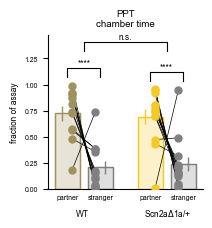

In [179]:
# ----- DO MIXED EFFECTS ANALYSIS IN CONJUNCTION WITH PLOTTING -----

savefigs = False

scol = [0.5,0.5,0.5]
cols = fcols
lbls = ['partner','stranger']*2
xlab = ''
ylab = 'fraction of assay'
stat = 'chamber time'
ttl = f'PPT\n{stat}'
boxalpha = 0.25 # transparency for boxplot face color
boxwidth = 0.75

# programatically set positions
dotdist = 0.15
errdist = 0.15
psdist = 1
gtdist = 1.5
start = 0

# remodel tab
tabw = tab[['pair_tag','GT','fraction_partner','fraction_stranger']].copy()

tabl = pd.wide_to_long(
    tabw, stubnames="fraction", i=["pair_tag", "GT"], j="stim",sep='_',suffix=r"\w+",
).reset_index()

pair_num = tabl.pair_tag.transform(lambda x: int(x.strip('Pair')))
tabl['subject'] = pair_num

md = smf.mixedlm("fraction ~ C(stim,Treatment('partner')) + C(GT)", tabl, groups=tabl['subject'])
mdf = md.fit()
print(mdf.summary())

# get pvalues to plot
gtp = mdf.wald_test_terms().pvalues[2]
partnerp = mdf.wald_test_terms().pvalues[1]

# process pvalues into text
gtp_text = decide_pval_text(gtp,0.05)
partnerp_text = decide_pval_text(partnerp,0.05)

# make figure
fig, ax = plt.subplots(figsize=figsz)

stat_base = 'fraction'

# --- PLOT WT DATA ---
df = tabw[tabw['GT']=='WT'].copy().reset_index(drop=True) # configure data to WT
pcol = fcols[0]
add_pair_to_plot(df,stat_base,ax,pcol,scol,start,dotdist,errdist,psdist,partnerp_text)

# --- PLOT HET DATA ---
df = tabw[tabw['GT']=='Het'].copy().reset_index(drop=True) # configure data to Het
pcol = fcols[1]
add_pair_to_plot(df,stat_base,ax,pcol,scol,start+psdist+gtdist,dotdist,errdist,psdist,partnerp_text)

# --- ADD STATS ANNOTATION ---
# plot stats test result
bottom, top = plt.ylim()  # return the current ylim
y, h = top + ppad*top, ppad
px1 = start+psdist/2
px2 = start+psdist+gtdist+psdist/2
ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
plt.text((px1+px2)*.5, y+h+0.1*h, gtp_text, ha='center', va='bottom', color='k',size=6)

# --- GENERAL PLOT STUFF ---
# remove axis lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_visible(False)

# adjust labeling parameters
ax.set_xticks([start,start+psdist,start+psdist+gtdist,start+psdist+gtdist+psdist],labels=lbls)
ax.set_yticks([0,0.25,0.5,0.75,1.0,1.25])
ax.tick_params(axis='x', which='both',length=0)
ax.set_xlabel(xlab)
ax.set_ylabel(ylab)
ax.set_title(ttl)
fig.text(0.3, -0.025, 'WT', ha='center',size=6)
fig.text(0.725, -0.025, 'Scn2a$ \Delta $1a/+', ha='center',size=6)

# save
if savefigs:
    plt.savefig(fname,bbox_inches='tight')

In [173]:
mdf.wald_test_terms().pvalues[2]

array(0.9885308)

C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge

                        Mixed Linear Model Regression Results
Model:                       MixedLM           Dependent Variable:           fraction
No. Observations:            46                Method:                       REML    
No. Groups:                  23                Scale:                        0.0340  
Min. group size:             2                 Log-Likelihood:               6.9434  
Max. group size:             2                 Converged:                    No      
Mean group size:             2.0                                                     
-------------------------------------------------------------------------------------
                                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------
Intercept                                  0.746    0.048  15.419 0.000  0.651  0.841
C(stim, Treatment('partner'))[T.stranger] -0.568    0.054 -10.434 0.000 -0.674

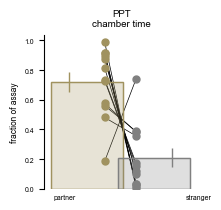

In [118]:
# ----- OLD BROKEN DO MIXED EFFECTS ANALYSIS IN CONJUNCTION WITH PLOTTING -----

savefigs = False

scol = [0.5,0.5,0.5]
cols = fcols
lbls = ['partner','stranger']
xlab = ''
ylab = 'fraction of assay'
stat = 'chamber time'
ttl = f'PPT\n{stat}'
spacer = 2.5-dotadj
boxalpha = 0.25 # transparency for boxplot face color

isnormal=True

# programatically set positions
dotdist = 0.2
errdist = 0.2
psdist = 0.75
gtdist = 1
start = 0

# remove outliers and check for normality

# remodel tab
tabw = tab[['pair_tag','GT','fraction_partner','fraction_stranger']].copy()

tabl = pd.wide_to_long(
    tabw, stubnames="fraction", i=["pair_tag", "GT"], j="stim",sep='_',suffix=r"\w+",
).reset_index()

pair_num = tabl.pair_tag.transform(lambda x: int(x.strip('Pair')))
tabl['subject'] = pair_num

md = smf.mixedlm("fraction ~ C(stim,Treatment('partner')) + C(GT)", tabl, groups=tabl['subject'])
mdf = md.fit()
print(mdf.summary())

# get pvalues to plot
gtp = mdf.wald_test_terms().pvalues[2]
partnerp = mdf.wald_test_terms().pvalues[1]

# process pvalues into text
gtp_text = decide_pval_text(gtp,0.05)
partnerp_text = decide_pval_text(partnerp,0.05)

# make figure
fig, ax = plt.subplots(figsize=figsz)

# --- PLOT WT DATA ---

# configure data to WT
df = tabw[tabw['GT']=='WT'].copy().reset_index(drop=True)

# -- PARTNER --
statkey = 'fraction_partner'
tcol = cols[0]

# plot partner dots
ax.plot(np.zeros(df.shape[0])+start+dotdist, df[statkey], 'o', markerfacecolor=cols[0],markeredgecolor=cols[0],zorder=1, ms=5, mew=1, alpha = 1)

# plot partner bar and error
tmean = np.mean(df[statkey])
se = scipy.stats.sem(df[statkey])
bplot = ax.bar(start,tmean,edgecolor=tcol)
ax.errorbar(start-errdist,tmean,yerr=se,ecolor=tcol,elinewidth=boxlw)
ax.bar(start,tmean,edgecolor=tcol,facecolor='None')

for patch in bplot:
    patch.set_facecolor(tcol)
    patch.set_alpha(boxalpha)

# -- STRANGER --    
statkey = 'fraction_stranger'
tcol = scol

# plot stranger dots
ax.plot(np.zeros(df.shape[0])+start+psdist-dotdist, df[statkey], 'o', markerfacecolor=tcol,markeredgecolor=tcol,zorder=1, ms=5, mew=1, alpha = 1)

# plot stranger bar and error
tmean = np.mean(df[statkey])
se = scipy.stats.sem(df[statkey])
bplot = ax.bar(start+psdist,tmean,edgecolor=tcol)
ax.errorbar(start+psdist+errdist,tmean,yerr=se,ecolor=tcol,elinewidth=boxlw)
ax.bar(start+psdist,tmean,edgecolor=tcol,facecolor='None')  

for patch in bplot:
    patch.set_facecolor(tcol)
    patch.set_alpha(boxalpha)

# plot pair lines
for idx in df.index: ax.plot([start+dotdist,start+psdist-dotdist], df.loc[idx,['fraction_partner','fraction_stranger']], 
                             color = 'k', linewidth = 0.5, linestyle = '-', zorder=-1)

# --- GENERAL PLOT STUFF ---
# remove axis lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# adjust labeling parameters
ax.set_xticks([0+(0.5*dotadj),1-(0.5*dotadj)],labels=lbls)
ax.tick_params(axis='x', which='both',length=0)
ax.set_xlabel(xlab)
ax.set_ylabel(ylab)
ax.set_title(ttl)

# save
if savefigs:
    plt.savefig(fname,bbox_inches='tight')

In [27]:
output=mdf.summary()
output

<class 'statsmodels.iolib.summary2.Summary'>
"""
                       Mixed Linear Model Regression Results
====================================================================================
Model:                      MixedLM           Dependent Variable:           fraction
No. Observations:           50                Method:                       REML    
No. Groups:                 25                Scale:                        0.0571  
Min. group size:            2                 Log-Likelihood:               -4.2362 
Max. group size:            2                 Converged:                    No      
Mean group size:            2.0                                                     
------------------------------------------------------------------------------------
                                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------
Intercept                                  0.707    0.058 12.114 0.000  0.592  0.821
C(stim, Treatment('partner'))[T.stranger] -0.484    0.068 -7.160 0.000 -0.616 -0.351
C(GT)[T.WT]                                0.001    0.069  0.014 0.989 -0.134  0.136
Group Var                                  0.001                                    
====================================================================================

"""

In [32]:
dir(mdf)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_cache',
 '_data_attr',
 '_data_in_cache',
 '_expand_re_names',
 '_get_robustcov_results',
 '_get_wald_nonlinear',
 '_transform_predict_exog',
 '_use_t',
 'aic',
 'bic',
 'bootstrap',
 'bse',
 'bse_fe',
 'bse_re',
 'bsejac',
 'bsejhj',
 'conf_int',
 'converged',
 'cov_params',
 'cov_pen',
 'cov_re',
 'cov_re_unscaled',
 'covjac',
 'covjhj',
 'df_modelwc',
 'df_resid',
 'f_test',
 'fe_params',
 'fittedvalues',
 'freepat',
 'get_nlfun',
 'hessv',
 'hist',
 'initialize',
 'k_constant',
 'k_fe',
 'k_re',
 'k_re2',
 'k_vc',
 'llf',
 'load',
 'method',
 'model',
 'nobs',
 'normalized_cov_params',
 'params',
 'params_object',
 

In [50]:
mdf.wald_test_terms().pvalues[2]

array(0.9885308)

In [53]:
tabw

,pair_tag,GT,fraction_partner,fraction_stranger
0,Pair1,Het,0.435308,0.314734
1,Pair15,Het,0.771046,0.158518
2,Pair16,WT,0.917656,0.033892
3,Pair2,WT,0.560261,0.386785
4,Pair21,Het,0.806026,0.156404
5,Pair22,Het,0.696381,0.145237
6,Pair23,Het,0.735543,0.231798
7,Pair28,Het,0.473239,0.489877
8,Pair29,Het,0.914799,0.045465
9,Pair3,Het,0.952270,0.016131


In [44]:
pair_num = tabl.pair_tag.transform(lambda x: int(x.strip('Pair')))
tabl['subject'] = pair_num
tabl

,pair_tag,GT,stim,fraction,subject
0,Pair16,WT,partner,0.917656,16
1,Pair16,WT,stranger,0.033892,16
2,Pair2,WT,partner,0.560261,2
3,Pair2,WT,stranger,0.386785,2
4,Pair31,WT,partner,0.736319,31
5,Pair31,WT,stranger,0.172610,31
6,Pair35,WT,partner,0.988746,35
7,Pair35,WT,stranger,0.004974,35
8,Pair4,WT,partner,0.874838,4
9,Pair4,WT,stranger,0.097879,4


In [18]:
tabw

,pair_tag,GT,fraction_partner,fraction_stranger
0,Pair16,WT,0.917656,0.033892
1,Pair2,WT,0.560261,0.386785
2,Pair31,WT,0.736319,0.172610
3,Pair35,WT,0.988746,0.004974
4,Pair4,WT,0.874838,0.097879
5,Pair56,WT,0.729606,0.156708
6,Pair59,WT,0.185931,0.741249
7,Pair61,WT,0.896430,0.021796
8,Pair62,WT,0.914997,0.031610
9,Pair63,WT,0.813758,0.118710


In [10]:
# ----- NORMALITY TEST FOR MALES -----
# test individual groups, test differences for normality
tab = chamber[chamber['sex']=='M'].copy().reset_index(drop=True)
gts = ['WT','Het']
stims = ['partner','stranger']
norm_decisions = []
for gt in gts:
    for stim in stims:
        stimstring = f'fraction_{stim}'
        this_norm = testNormal(tab[tab['GT']==gt].copy().reset_index(drop=True)[stimstring])
        print(this_norm)
        norm_decisions.append(this_norm[0])

(True, [0.2782, 0.8196], 'Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness)')
(True, [0.1654, 0.4222], 'Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness)')
(True, [0.2374, 0.5726], 'Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness)')
(False, [0.0346, 0.1882], 'Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness)')


In [43]:
# ----- REMOVE OUTLIERS FROM MALE DATA -----
sex = 'male'
if sex == 'male':
    sl = 'M'
else:
    sl = 'F'
    
tab = chamber[chamber['sex']==sl].copy().reset_index(drop=True)
gts = ['WT','Het']
stims = ['partner','stranger']
alltabs = []
for gt in gts:
    n = np.sum(tab['GT']==gt)
    gttab = tab[tab['GT']==gt].copy().reset_index(drop=True)
    usedat = np.zeros(1,n)
    for stim in stims:
        print(f'Finding outliers for {gt} {sex} with {stim}.')
        stimstring = f'fraction_{stim}'
        thisdat = tab[tab['GT']==gt].copy().reset_index(drop=True)[stimstring]

        first_quar = np.percentile(thisdat, 25)
        third_quar = np.percentile(thisdat, 75)
        IQR = third_quar - first_quar

        lower_limit = first_quar - 1.5 * IQR
        upper_limit = third_quar + 1.5 * IQR

        outliers_iqr = scipy.stats.iqr(thisdat, nan_policy='omit', axis=0, rng=(25, 75)) * 1.5
        outliers = np.where((thisdat < lower_limit) | (thisdat > upper_limit))[0]
        print("Outliers detected using IQR:", outliers)
        
        outliersIdx = np.logical_and(thisdat>lower_limit,thisdat<upper_limit)
        usedat = np.logical_or(usedat,outliersIdx)
    gttab['outlier_use'] = usedat
    alltabs.append(gttab)
    
outliertab = pd.concat(alltabs).reset_index(drop=True)

Finding outliers for WT male with partner.
Outliers detected using IQR: []
Finding outliers for WT male with stranger.
Outliers detected using IQR: []
Finding outliers for Het male with partner.
Outliers detected using IQR: []
Finding outliers for Het male with stranger.
Outliers detected using IQR: [7]


In [42]:
# test males for outliers -> shouldn't be any if they're already passing normal test
# do two way repeat measures anova for stats
# implement earth movers distance permutation test for preference index

In [ ]:
# ----- CALCULATE PARTNER/STRANGER HUDDLE TIMES -----

In [ ]:
# ----- CALCULATE PREFERENCE INDEX -----

In [ ]:
# ----- MAKE PLOTS -----

In [30]:
df = pingouin.read_dataset('rm_anova')

In [31]:
df

,Subject,Gender,Region,Education,DesireToKill,Disgustingness,Frighteningness
0,1,Female,North,some,10.0,High,High
1,1,Female,North,some,9.0,High,Low
2,1,Female,North,some,6.0,Low,High
3,1,Female,North,some,6.0,Low,Low
4,2,Female,North,advance,10.0,High,High
...,...,...,...,...,...,...,...
367,99,Female,North,some,9.0,Low,Low
368,100,Female,Europe,some,3.0,High,High
369,100,Female,Europe,some,2.0,High,Low
370,100,Female,Europe,some,5.5,Low,High


In [32]:
df.DesireToKill

0      10.0
1       9.0
2       6.0
3       6.0
4      10.0
       ... 
367     9.0
368     3.0
369     2.0
370     5.5
371     5.5
Name: DesireToKill, Length: 372, dtype: float64

In [47]:
aov = pingouin.rm_anova(dv='DesireToKill', within=['Disgustingness', 'Frighteningness'],
                  subject='Subject', data=df)

C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\pingouin\distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\pingouin\distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


In [48]:
aov

,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,Disgustingness,48.752841,1,87,48.752841,12.175190,7.623808e-04,7.623808e-04,0.018554,1.0
1,Frighteningness,177.556818,1,87,177.556818,41.629663,6.011447e-09,6.011447e-09,0.064415,1.0
2,Disgustingness * Frighteningness,6.545455,1,87,6.545455,2.152300,1.459622e-01,1.459622e-01,0.002532,1.0


In [52]:
data = sm.datasets.get_rdataset("dietox", "geepack").data

In [53]:
data

,Pig,Evit,Cu,Litter,Start,Weight,Feed,Time
0,4601,Evit000,Cu000,1,26.5,26.50000,NaN,1
1,4601,Evit000,Cu000,1,26.5,27.59999,5.200005,2
2,4601,Evit000,Cu000,1,26.5,36.50000,17.600000,3
3,4601,Evit000,Cu000,1,26.5,40.29999,28.500000,4
4,4601,Evit000,Cu000,1,26.5,49.09998,45.200001,5
...,...,...,...,...,...,...,...,...
856,8442,Evit000,Cu175,24,25.7,73.19995,83.800003,8
857,8442,Evit000,Cu175,24,25.7,81.69995,99.800003,9
858,8442,Evit000,Cu175,24,25.7,90.29999,115.200001,10
859,8442,Evit000,Cu175,24,25.7,96.00000,133.200001,11


In [54]:
np.unique(data.Time)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])